# Window-level DIS Discontinuity Check (fixed clock-aligned windows)

**Follow-up to `image_level_discontinuity_check.ipynb`.** That notebook grouped images by
*exact request* (`timestamp` value) and checked, in `device_capture_time` order, whether one
request's images ever interleaved with another's.

This notebook uses the **same underlying interleaving test**, but groups requests into
**fixed, clock-aligned windows of length `WL`** first (`window_id = floor(epoch_seconds(timestamp)
/ (WL * 60))` — the same fixed-window scheme as the earlier "method one" production design),
for `WL ∈ {10, 15, 30, 60} minutes`:

> Bucket every request into a window by its arrival `timestamp`. Pool all images across all
> windows for a vehicle and sort by `device_capture_time`. If any image whose request falls in
> window `w1` sorts, in dct order, in a way that interleaves with images from a different window
> `w2` (rather than every `w1` image sitting cleanly before/after every `w2` image), that's a
> **discontinuity** — an image that, from `device_capture_time`'s perspective, doesn't belong
> where its fixed window says it does.

We want, per vehicle **and** fleet-wide, for **each window length**: the count and percentage of
images and windows involved.


## Method

Identical run-length approach as the request-level notebook, just with the run label swapped
from "raw request timestamp" to "window id":

1. For a given `WL`, compute `window_id` per image from its request `timestamp`
   (`floor(epoch_seconds / (WL*60))`) — a pure function of the timestamp, no per-vehicle state.
2. Sort all of a vehicle's images by `device_capture_time`; run-length encode `window_id` over
   that order.
3. A window whose images land in more than one run has been split by another window's images —
   every image in a non-first run for its window is a **discontinuous image**.

Because window assignment only depends on each image's own request `timestamp`, this reuses the
exact same `compute_discontinuity` core function from the previous notebook — only the label
column changes (`window_id` instead of `timestamp`). Loading each vehicle's CSV once and
recomputing `window_id` for all 4 window lengths avoids re-reading data per window length.

**Caveat carried over from the fixed-window production design**: window boundaries are anchored
to the Unix epoch, not to anything in the data — an arbitrary phase choice. Unlike the
request-level notebook (where grouping boundaries are the real, data-driven request
arrivals), a fixed window can slice a cluster of temporally-close requests in two just because
their timestamps straddle a boundary. Results below are therefore partly an artifact of this
alignment choice, not purely a property of the data — exactly the tradeoff the production
"fixed clock-aligned window" scheme accepts for simplicity/shared-window benefits.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

# --- Local Mac paths ---
TOP_10K_DIR = "/Users/swapnilmane/NetraDyne/DIS_logic/top_10k"
VALID_PAIRS_FILE = "/Users/swapnilmane/NetraDyne/DIS_logic/valid_tenant_vehicle_pairs.csv"
SYSTEM_DESIGN_DIR = "/Users/swapnilmane/NetraDyne/DIS_logic/system_design"
# --- Cloud instance paths (uncomment if running there instead) ---
# TOP_10K_DIR = "/home/ubuntu/dis_analysis/top_10k"
# VALID_PAIRS_FILE = "/home/ubuntu/dis_analysis/valid_tenant_vehicle_pairs.csv"
# SYSTEM_DESIGN_DIR = "/home/ubuntu/dis_analysis/system_design"

PROCESSED_IMAGES_TEMPLATE = os.path.join(TOP_10K_DIR, "processed_csv", "processed_images_{tenant_id}_{vehicle_id}.csv")
OUTPUT_DIR = os.path.join(SYSTEM_DESIGN_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DCT_COL = "device_capture_time"
TS_COL = "timestamp"
WINDOW_LENGTHS_MINUTES = [10, 15, 30, 60]
MAX_WORKERS = 8


/Users/swapnilmane/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Core metric -- identical to image_level_discontinuity_check.ipynb, generalized to any
# label column (there: raw request timestamp; here: fixed-window id derived from it).
def compute_discontinuity(df, dct_col, label_col):
    d = df[[dct_col, label_col]].dropna()
    dropped_missing = len(df) - len(d)

    if d.empty:
        return {
            "total_images": 0,
            "dropped_missing": dropped_missing,
            "discontinuous_images": 0,
            "discontinuous_pct": np.nan,
            "total_labels": 0,
            "affected_labels": 0,
            "affected_labels_pct": np.nan,
            "num_runs": 0,
        }

    d = d.sort_values(dct_col, kind="mergesort").reset_index(drop=True)

    labels = d[label_col].to_numpy()
    run_id = np.zeros(len(labels), dtype=np.int64)
    run_id[1:] = (labels[1:] != labels[:-1]).cumsum()
    d["_run_id"] = run_id

    run_first_label = d.groupby("_run_id")[label_col].first()
    first_run_per_label = run_first_label.reset_index().groupby(label_col)["_run_id"].min()
    d["_first_run_for_label"] = d[label_col].map(first_run_per_label)

    is_extra_run_image = d["_run_id"] != d["_first_run_for_label"]
    discontinuous_images = int(is_extra_run_image.sum())
    total_images = len(d)

    runs_per_label = d.groupby(label_col)["_run_id"].nunique()
    affected_labels = int((runs_per_label > 1).sum())
    total_labels = int(runs_per_label.shape[0])

    return {
        "total_images": total_images,
        "dropped_missing": dropped_missing,
        "discontinuous_images": discontinuous_images,
        "discontinuous_pct": 100.0 * discontinuous_images / total_images,
        "total_labels": total_labels,
        "affected_labels": affected_labels,
        "affected_labels_pct": 100.0 * affected_labels / total_labels,
        "num_runs": int(d["_run_id"].nunique()),
    }


def add_window_id(df, ts_col, window_minutes):
    d = df.copy()
    dropped_missing_timestamp = int(d[ts_col].isna().sum())
    d = d.dropna(subset=[ts_col])
    epoch_seconds = d[ts_col].astype("int64") // 10**9
    d["_window_id"] = epoch_seconds // (window_minutes * 60)
    return d, dropped_missing_timestamp


def analyze_vehicle_for_window(df, window_minutes, dct_col=DCT_COL, ts_col=TS_COL):
    d, dropped_missing_timestamp = add_window_id(df, ts_col, window_minutes)
    result = compute_discontinuity(d, dct_col=dct_col, label_col="_window_id")
    result["dropped_missing_timestamp"] = dropped_missing_timestamp
    result["dropped_missing_dct"] = result.pop("dropped_missing")
    result["total_windows"] = result.pop("total_labels")
    result["affected_windows"] = result.pop("affected_labels")
    result["affected_windows_pct"] = result.pop("affected_labels_pct")
    return result


In [3]:
# Worked toy example: same interleaving pattern as the request-level notebook's toy test, but
# window ids are now derived from real timestamps via floor-division instead of given directly.
# WL = 10 min (600s). Two requests: one at t=0 (window 0), one at t=12min (window 1, since
# 12*60=720s // 600 = 1). dct-sorted request-id sequence ends up window0,window0,window1,window0,window1
# -- identical shape to the earlier toy example -> 2 discontinuous images, both windows affected.
base = pd.Timestamp("2026-01-01 00:00:00")
toy_raw = pd.DataFrame({
    DCT_COL: [1, 2, 3, 4, 5],
    TS_COL: [base, base, base + pd.Timedelta(minutes=12), base, base + pd.Timedelta(minutes=12)],
})
toy_result = analyze_vehicle_for_window(toy_raw, window_minutes=10)
assert toy_result["discontinuous_images"] == 2
assert toy_result["total_images"] == 5
assert toy_result["total_windows"] == 2
assert toy_result["affected_windows"] == 2
print("Toy example sanity check passed:", toy_result)


Toy example sanity check passed: {'total_images': 5, 'discontinuous_images': 2, 'discontinuous_pct': 40.0, 'num_runs': 4, 'dropped_missing_timestamp': 0, 'dropped_missing_dct': 0, 'total_windows': 2, 'affected_windows': 2, 'affected_windows_pct': 100.0}


In [4]:
def load_vehicle_df(tenant_id, vehicle_id):
    path = PROCESSED_IMAGES_TEMPLATE.format(tenant_id=tenant_id, vehicle_id=vehicle_id)
    df = pd.read_csv(path, usecols=[TS_COL, DCT_COL], engine="pyarrow")
    df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")
    df[DCT_COL] = pd.to_datetime(df[DCT_COL], errors="coerce")
    return df


def analyze_vehicle(tenant_id, vehicle_id):
    rows = []
    try:
        df = load_vehicle_df(tenant_id, vehicle_id)
        for wl in WINDOW_LENGTHS_MINUTES:
            result = analyze_vehicle_for_window(df, wl)
            result["error"] = None
            result["window_length_minutes"] = wl
            result["tenant_id"] = tenant_id
            result["vehicle_id"] = vehicle_id
            rows.append(result)
    except Exception as e:
        err = str(e)
        for wl in WINDOW_LENGTHS_MINUTES:
            rows.append({
                "tenant_id": tenant_id, "vehicle_id": vehicle_id,
                "window_length_minutes": wl, "error": err,
            })
    return rows


In [5]:
valid_pairs_df = pd.read_csv(VALID_PAIRS_FILE)
pairs = list(valid_pairs_df[["tenant_id", "vehicle_id"]].itertuples(index=False, name=None))
print(f"{len(pairs)} (tenant_id, vehicle_id) pairs x {len(WINDOW_LENGTHS_MINUTES)} window lengths to process")

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(analyze_vehicle, t, v): (t, v) for t, v in pairs}
    for future in tqdm(as_completed(futures), total=len(futures)):
        t, v = futures[future]
        try:
            results.extend(future.result(timeout=300))
        except Exception as e:
            for wl in WINDOW_LENGTHS_MINUTES:
                results.append({"tenant_id": t, "vehicle_id": v, "window_length_minutes": wl, "error": str(e)})

results_df = pd.DataFrame(results)
leading_cols = ["tenant_id", "vehicle_id", "window_length_minutes"]
other_cols = [c for c in results_df.columns if c not in leading_cols]
results_df = results_df[leading_cols + other_cols]

n_errors = results_df["error"].notna().sum()
print(f"rows = {len(results_df)} ({len(results_df) // len(WINDOW_LENGTHS_MINUTES)} vehicles x {len(WINDOW_LENGTHS_MINUTES)} window lengths), error rows = {n_errors}")

vehicle_results_path = os.path.join(OUTPUT_DIR, "vehicle_level_window_discontinuity_results.csv")
results_df.to_csv(vehicle_results_path, index=False)
print(f"Wrote {vehicle_results_path}")
results_df.head()


6364 (tenant_id, vehicle_id) pairs x 4 window lengths to process


  0%|          | 0/6364 [00:00<?, ?it/s]

  0%|          | 10/6364 [00:00<01:21, 77.80it/s]

  0%|          | 19/6364 [00:00<01:16, 82.56it/s]

  0%|          | 30/6364 [00:00<01:07, 93.83it/s]

...

100%|█████████▉| 6346/6364 [01:10<00:00, 89.87it/s]

100%|█████████▉| 6356/6364 [01:10<00:00, 88.16it/s]

100%|██████████| 6364/6364 [01:10<00:00, 90.12it/s]

rows = 25456 (6364 vehicles x 4 window lengths), error rows = 4
Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/vehicle_level_window_discontinuity_results.csv


,tenant_id,vehicle_id,window_length_minutes,total_images,discontinuous_images,discontinuous_pct,num_runs,dropped_missing_timestamp,dropped_missing_dct,total_windows,affected_windows,affected_windows_pct,error
0,20559,1348866,10,23.0,0.0,0.0,6.0,0.0,0.0,6.0,0.0,0.0,None
1,20559,1348866,15,23.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,None
2,20559,1348866,30,23.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,None
3,20559,1348866,60,23.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0,None
4,25836,3704523,10,752.0,0.0,0.0,135.0,0.0,0.0,135.0,0.0,0.0,None


## Vehicle-level results, per window length

In [6]:
ok = results_df[results_df["error"].isna()].copy()
if n_errors:
    n_error_vehicles = results_df.loc[results_df["error"].notna(), ["tenant_id", "vehicle_id"]].drop_duplicates().shape[0]
    print(f"Excluding {n_error_vehicles} vehicle(s) with errors from the analysis below:")
    display(results_df.loc[results_df["error"].notna(), ["tenant_id", "vehicle_id", "error"]].drop_duplicates().head(20))

print("\\nPer-vehicle discontinuous_pct (image-level), by window length:")
display(ok.groupby("window_length_minutes")["discontinuous_pct"].describe())

print("\\nPer-vehicle affected_windows_pct (window-level), by window length:")
display(ok.groupby("window_length_minutes")["affected_windows_pct"].describe())

ok.sort_values(["window_length_minutes", "discontinuous_pct"], ascending=[True, False]).groupby("window_length_minutes").head(5)[
    ["window_length_minutes", "tenant_id", "vehicle_id", "total_images", "discontinuous_images", "discontinuous_pct",
     "total_windows", "affected_windows", "affected_windows_pct"]
]


Excluding 1 vehicle(s) with errors from the analysis below:


,tenant_id,vehicle_id,error
4800,14233,1079659,[Errno 2] No such file or directory: '/Users/s...


\nPer-vehicle discontinuous_pct (image-level), by window length:


,count,mean,std,min,25%,50%,75%,max
window_length_minutes,,,,,,,,
10,6363.0,0.627671,1.492482,0.0,0.0,0.0,0.651938,29.183673
15,6363.0,0.537549,1.418859,0.0,0.0,0.0,0.567934,31.224490
30,6363.0,0.431098,1.346554,0.0,0.0,0.0,0.000000,33.673469
60,6363.0,0.450252,1.512372,0.0,0.0,0.0,0.000000,35.306122


\nPer-vehicle affected_windows_pct (window-level), by window length:


,count,mean,std,min,25%,50%,75%,max
window_length_minutes,,,,,,,,
10,6363.0,0.466772,0.855285,0.0,0.0,0.0,0.696864,33.333333
15,6363.0,0.534123,1.065593,0.0,0.0,0.0,0.888889,40.000000
30,6363.0,0.505012,1.353465,0.0,0.0,0.0,0.000000,50.000000
60,6363.0,0.593348,1.745642,0.0,0.0,0.0,0.000000,50.000000


,window_length_minutes,tenant_id,vehicle_id,total_images,discontinuous_images,discontinuous_pct,total_windows,affected_windows,affected_windows_pct
21348,10,7113,2941897,490.0,143.0,29.183673,62.0,2.0,3.225806
13756,10,5884,323563,619.0,153.0,24.717286,75.0,2.0,2.666667
22280,10,6010,3776407,610.0,132.0,21.639344,80.0,2.0,2.500000
6944,10,7366,3689464,553.0,113.0,20.433996,61.0,4.0,6.557377
24812,10,6101,2286289,587.0,107.0,18.228279,74.0,8.0,10.810811
21349,15,7113,2941897,490.0,153.0,31.224490,44.0,2.0,4.545455
13757,15,5884,323563,619.0,161.0,26.009693,53.0,2.0,3.773585
17013,15,10343,1602871,28.0,7.0,25.000000,5.0,2.0,40.000000
22281,15,6010,3776407,610.0,132.0,21.639344,59.0,2.0,3.389831
6945,15,7366,3689464,553.0,106.0,19.168174,47.0,2.0,4.255319


Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/window_discontinuity_pct_distribution_by_wl.png


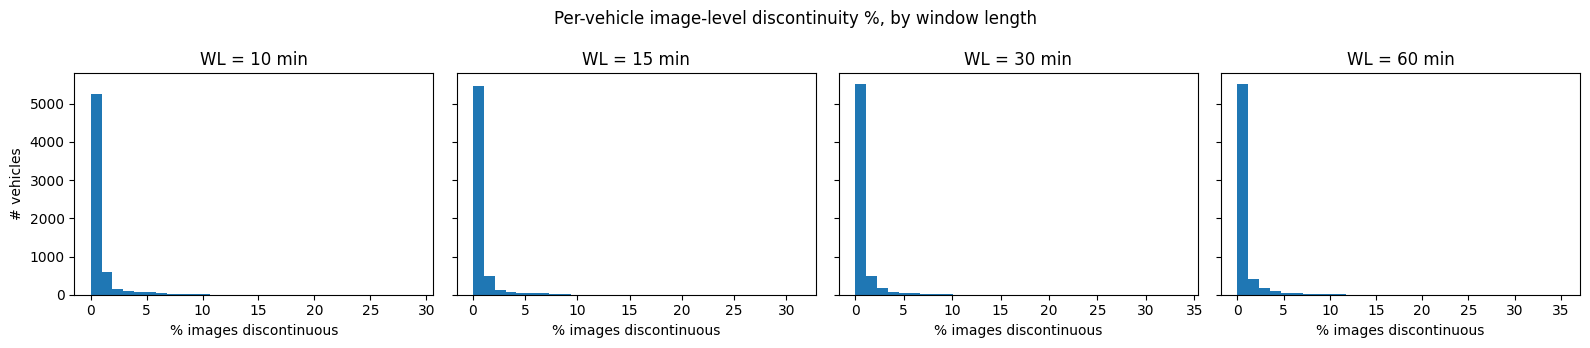

In [7]:
fig, axes = plt.subplots(1, len(WINDOW_LENGTHS_MINUTES), figsize=(4 * len(WINDOW_LENGTHS_MINUTES), 3.5), sharey=True)
for ax, wl in zip(axes, WINDOW_LENGTHS_MINUTES):
    ax.hist(ok.loc[ok["window_length_minutes"] == wl, "discontinuous_pct"].dropna(), bins=30)
    ax.set_title(f"WL = {wl} min")
    ax.set_xlabel("% images discontinuous")
axes[0].set_ylabel("# vehicles")
fig.suptitle("Per-vehicle image-level discontinuity %, by window length")
fig.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "window_discontinuity_pct_distribution_by_wl.png")
fig.savefig(plot_path, dpi=150)
print(f"Wrote {plot_path}")
plt.show()


## Overall (fleet-wide) results, per window length

In [8]:
overall_rows = []
for wl, group in ok.groupby("window_length_minutes"):
    overall_rows.append({
        "window_length_minutes": wl,
        "vehicles_processed": int(len(group)),
        "total_images": int(group["total_images"].sum()),
        "discontinuous_images": int(group["discontinuous_images"].sum()),
        "overall_discontinuous_image_pct": 100.0 * group["discontinuous_images"].sum() / group["total_images"].sum(),
        "mean_of_per_vehicle_discontinuous_pct": group["discontinuous_pct"].mean(),
        "median_of_per_vehicle_discontinuous_pct": group["discontinuous_pct"].median(),

        "total_windows": int(group["total_windows"].sum()),
        "affected_windows": int(group["affected_windows"].sum()),
        "overall_affected_window_pct": 100.0 * group["affected_windows"].sum() / group["total_windows"].sum(),
        "mean_of_per_vehicle_affected_windows_pct": group["affected_windows_pct"].mean(),
        "median_of_per_vehicle_affected_windows_pct": group["affected_windows_pct"].median(),
    })

overall_df = pd.DataFrame(overall_rows).sort_values("window_length_minutes").reset_index(drop=True)
overall_path = os.path.join(OUTPUT_DIR, "overall_window_discontinuity_summary.csv")
overall_df.to_csv(overall_path, index=False)
print(f"Wrote {overall_path}")
overall_df


Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/overall_window_discontinuity_summary.csv


,window_length_minutes,vehicles_processed,total_images,discontinuous_images,overall_discontinuous_image_pct,mean_of_per_vehicle_discontinuous_pct,median_of_per_vehicle_discontinuous_pct,total_windows,affected_windows,overall_affected_window_pct,mean_of_per_vehicle_affected_windows_pct,median_of_per_vehicle_affected_windows_pct
0,10,6363,8437627,61811,0.732564,0.627671,0.0,1591407,7702,0.483974,0.466772,0.0
1,15,6363,8437627,51641,0.612032,0.537549,0.0,1134540,6133,0.540572,0.534123,0.0
2,30,6363,8437627,41048,0.486487,0.431098,0.0,635134,3223,0.507452,0.505012,0.0
3,60,6363,8437627,43697,0.517883,0.450252,0.0,352342,2132,0.605094,0.593348,0.0


Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/overall_window_discontinuity_vs_wl.png


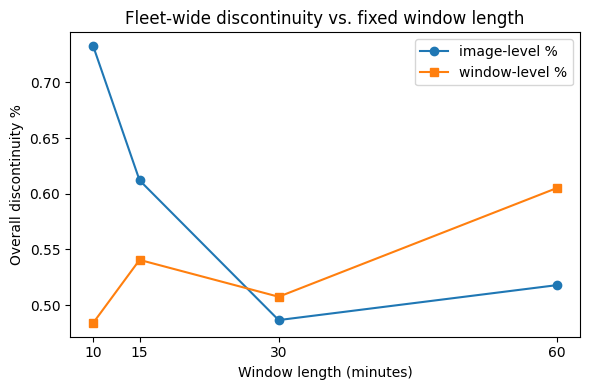

In [9]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(overall_df["window_length_minutes"], overall_df["overall_discontinuous_image_pct"], marker="o", label="image-level %")
ax1.plot(overall_df["window_length_minutes"], overall_df["overall_affected_window_pct"], marker="s", label="window-level %")
ax1.set_xlabel("Window length (minutes)")
ax1.set_ylabel("Overall discontinuity %")
ax1.set_title("Fleet-wide discontinuity vs. fixed window length")
ax1.set_xticks(WINDOW_LENGTHS_MINUTES)
ax1.legend()
fig.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "overall_window_discontinuity_vs_wl.png")
fig.savefig(plot_path, dpi=150)
print(f"Wrote {plot_path}")
plt.show()


## Notes / caveats

- **Window scheme**: fixed, clock-aligned, epoch-anchored (`window_id = floor(epoch_seconds /
  (WL*60))`) — the same scheme as the production "method one" design, not a per-vehicle relative
  or dynamic/idle-cutoff scheme. Results reflect this specific, arbitrary phase alignment.
- **Reused algorithm**: the interleaving/run-length test itself is unchanged from
  `image_level_discontinuity_check.ipynb` — only the grouping label changed from "raw request
  timestamp" to "window id derived from that timestamp". A vehicle's `discontinuous_pct` here is
  expected to be `<=` its request-level counterpart for large enough `WL` (a window can only
  merge requests together, never split what was already one request), assuming no tie-breaking
  edge cases at window boundaries.
- **Missing data**: `dropped_missing_timestamp` (can't be windowed, dropped before window-id
  assignment) and `dropped_missing_dct` (dropped by the shared `compute_discontinuity` core) are
  tracked separately per vehicle/window-length in the results CSV.
- Each vehicle's source CSV is read once and reused across all 4 window lengths (window id is
  cheap to recompute), not re-read per window length.
